# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 3: RNN и языковые модели 

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 12.75, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 7.83 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 15 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в архиве `jokes.txt.zip`, который доступен по [ссылке](https://disk.yandex.com/d/fjt5xICH-ukEEA).

In [2]:
import sys
import os

path = '/kaggle/input/datasets/shaykoaleksandr/please-work'
sys.path.append(path)

## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [3]:
!pip install sentencepiece

In [4]:
import torch
import numpy as np
from dataset import TextDataset

In [5]:
train_set = TextDataset(data_file=os.path.join(path, 'jokes.txt'), train=True, sp_model_prefix='bpe')
valid_set = TextDataset(os.path.join(path, 'jokes.txt'), train=False, sp_model_prefix='bpe')

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /kaggle/input/datasets/shaykoaleksandr/please-work/jokes.txt
  input_format: 
  model_prefix: bpe
  model_type: BPE
  vocab_size: 2000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  

In [6]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length, )
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1:] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (3.5 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [7]:
from model import LanguageModel

In [8]:
model = LanguageModel(train_set)

In [9]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs, ))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ['', 'купил мужик шляпу,', 'сел медведь в машину и', 'подумал штирлиц']:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (2 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://towardsdatascience.com/perplexity-in-language-models-87a196019a94). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_set, 
    batch_size=64, 
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    valid_set, 
    batch_size=64, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

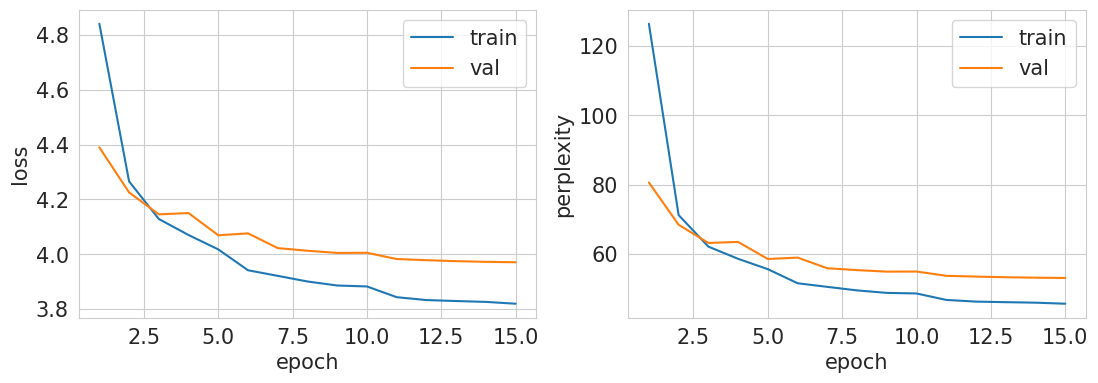

Generation examples:
вот пара подойдя на другую компьютерное сотруктной мавпереди евгений, то я слишком много говорящего.
- а ты не знаешь?- так он хоть бы деньги от - приключь предметы раскладаем. вум году будет обратно.
на даче и участливых и рем сане политические плаченко, было есть бабы, оставшим давали имяц и детей. что делать женщину надо свободного взста.
иногда, наверное, когда сегодня хотел переехать в том, что на австралиии по мужика сразу начался я была с корды с косточки - от унитаз дали у мно. муж не обращном общем, генерал лучше, чем вместе и моде я убеждать, что раньше делятся сам...
один дятей, в первый раз за композиции в разгат сказал костер.
RNN сохранили. Размер: 4524.3 KB


In [12]:
from train import train

model = LanguageModel(train_set).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train(model, optimizer, scheduler, train_loader, val_loader, num_epochs=15, num_examples=5)

torch.save(model.state_dict(), 'model.pth')
print(f"RNN сохранили. Размер: {os.path.getsize('model.pth') / 1024:.1f} KB")

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

In [13]:
import torch
import torch.nn as nn

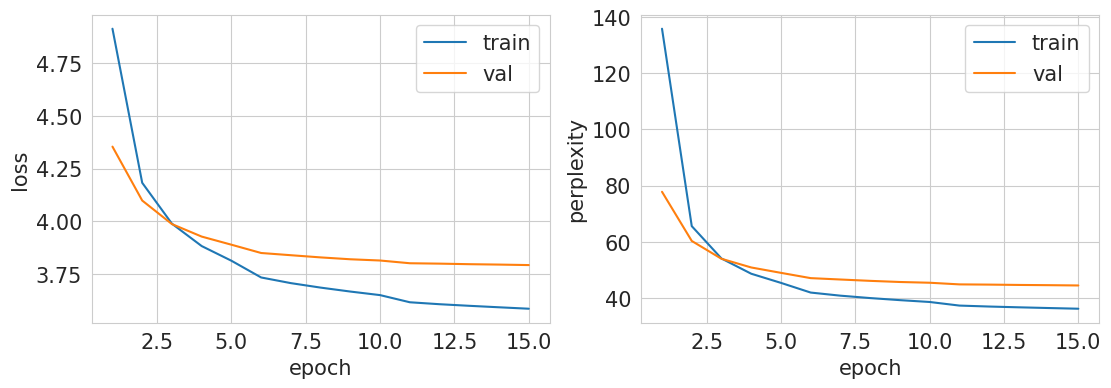

Generation examples:
девочка, что купила внучку дедушка!терапев- ищите взять?- да когда мне чудесая хорошо уже почти нравится.- а если еще нет работы?- навсегда, то они у них победят сам денег?
- свястите, у меня девушка не было...- а чего?- аппарат.
- когда узнала что ты нашел.- расскажите когда я есть себе настоящих поделиться перед звездой, они все это тоже лежит перед партию!
как дурак мясо, наши отношения погибший без сапоги.
сестренка - выщайте мне предложение отыскатье. чтобы тройнютом столь внимания, а не просто узких его заключивающий выпускство.
LSTM сохранили. Размер: 6066.6 KB


In [14]:
model_lstm = LanguageModel(train_set, rnn_type=nn.LSTM).to(device) 

optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
scheduler_lstm = torch.optim.lr_scheduler.StepLR(optimizer_lstm, step_size=5, gamma=0.5)

train(model_lstm, optimizer_lstm, scheduler_lstm, train_loader, val_loader, num_epochs=15, num_examples=5)

torch.save(model_lstm.state_dict(), 'model_lstm.pth')
print(f"LSTM сохранили. Размер: {os.path.getsize('model_lstm.pth') / 1024:.1f} KB")

Как мы можем видеть, LSTM показала себя лучше по значению метрик на трейне и валидации. Скорее всего, потому что у нее градиенты лучше текут за счет аналога skip-connections (чтобы градиенты не затухали и не раздувались и проходили по многим слоям) и модель потому лучше сходится. И по генерируемым текстам, как мне кажется, модель LSTM выдает уже более осознанные анекдоты, чем RNN. Это связано, как я понимаю, с тем, что LSTM умеет забывать ненужное и хранить важное через Forget и Input gates. Поэтому, например, у нас лучше модель понимает в каком роде будет глагол в конце предложения.

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [15]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
model_lstm.eval()
model.eval()
prefix_1 = "однажды школьника попросили рассказать самую грустную историю"
prefix_2 = "заходит как-то Боб в сарай и видит там"
prefix_3 = "шла как-то в одиноком поле молодая пара"
prefix_4 = "без него мы как без рук, а без Вани как без"

prefixes = [prefix_1, prefix_2, prefix_3, prefix_4]
temperatures = [0.1, 0.5, 2.0, 20.0, 1000.0]

print(20*'-' + "This is the LSTM model inference" + 20*'-')

for temp in temperatures:
    print(f"\n Temperature: {temp}\n")
    for pref in prefixes:
        generated_text = model_lstm.inference(pref, temp)
        print(f"Prefix: {pref}")
        print(f"Result: {generated_text}")

print(20*'-' + "This is the RNN model inference" + 20*'-')

for temp in temperatures:
    print(f"\n Temperature: {temp}\n")
    for pref in prefixes:
        generated_text = model.inference(pref, temp)
        print(f"Prefix: {pref}")
        print(f"Result: {generated_text}")

--------------------This is the LSTM model inference--------------------

 Temperature: 0.1

Prefix: однажды школьника попросили рассказать самую грустную историю
Result: однажды школьника попросили рассказать самую грустную историю.
Prefix: заходит как-то Боб в сарай и видит там
Result: заходит как-то боб в сарай и видит там ветер, а потом говорит- я не могу понять, что ты не знаешь, что это не устраивает, а в качестве.
Prefix: шла как-то в одиноком поле молодая пара
Result: шла как-то в одиноком поле молодая парашют.
Prefix: без него мы как без рук, а без Вани как без
Result: без него мы как без рук, а без вани как без макияжа.

 Temperature: 0.5

Prefix: однажды школьника попросили рассказать самую грустную историю
Result: однажды школьника попросили рассказать самую грустную историю. а я у нее даже не знаю, что это ты козел.
Prefix: заходит как-то Боб в сарай и видит там
Result: заходит как-то боб в сарай и видит там и говорит- милая, ты меня любишь?- нет, я на вас в сауне!
Prefix:

**Результаты:**
Как мы видим, поскольку при низкой температуре (Temp = 0.1) распределение вероятностей становится практически вырожденным, то модель выдает только те слова, в которых она наиболее уверенна. Когда же у нас температура высокая (Temp > 2.0), то поскольку распределение вероятностей становится практически равномерным, модель начинает просто вставлять практически случайные токены, которые вообще могут быть никак не связаны друг с другом. Плюс, шанс eos становится довольно низким (как и все остальные вероятности), а потому модель просто создает огромные предложения, пока не доходит до лимита по токенам. При значении температуры в 0.5 в LSTM даже получился диалог в одном из примеров со всеми необходимыми дефисами. И в целом видно, что предложения получаются неплохими, потому что распределение вероятностей и не очень вырожденное и не равномерное. Тем не менее, опять же на этих примерах видно, что LSTM лучше в целом сохраняет контекст и не теряет нить, создает более осмысленные предложения.

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

In [16]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

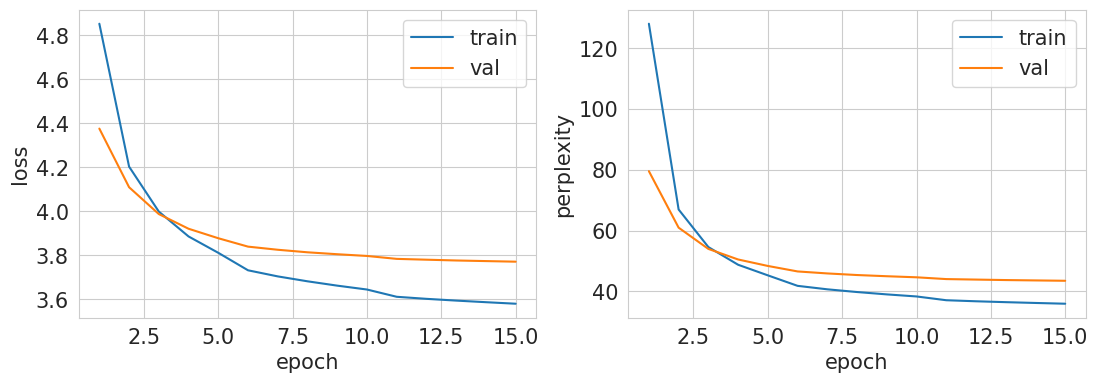

Generation examples:
- извините, я вас в супермаркетологической и пугает невестке, посчитал шоколадку, будет лишил вашинг. стремляю!- да я бы сигарет в дупе!
гуви от выходных жена - это жчу завалил.
больше всего просыпается комплименты. я - лягушку, а звук, это обычный...
- а почему у нас победи есть.- о, варианта, пока ты дернул на море, чем ей что-нибудь ценим?
при виде в мире российского рф бом пор рф.
LSTM с Unigram сохранили. Размер: 6066.7 KB


In [17]:
train_set_uni = TextDataset(data_file=os.path.join(path, 'jokes.txt'), train=True, sp_model_prefix='unigram', model_type='unigram')
valid_set_uni = TextDataset(os.path.join(path, 'jokes.txt'), train=False, sp_model_prefix='unigram', model_type = 'unigram')

train_loader_uni = DataLoader(
    train_set_uni, 
    batch_size=64, 
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_uni = DataLoader(
    valid_set_uni, 
    batch_size=64, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

model_lstm_uni = LanguageModel(train_set_uni, rnn_type=nn.LSTM).to(device) 

optimizer_lstm_uni = torch.optim.Adam(model_lstm_uni.parameters(), lr=1e-3)
scheduler_lstm_uni = torch.optim.lr_scheduler.StepLR(optimizer_lstm_uni, step_size=5, gamma=0.5)

train(model_lstm_uni, optimizer_lstm_uni, scheduler_lstm_uni, train_loader_uni, val_loader_uni, num_epochs=15, num_examples=5)

torch.save(model_lstm_uni.state_dict(), 'model_lstm_uni.pth')
print(f"LSTM с Unigram сохранили. Размер: {os.path.getsize('model_lstm_uni.pth') / 1024:.1f} KB")

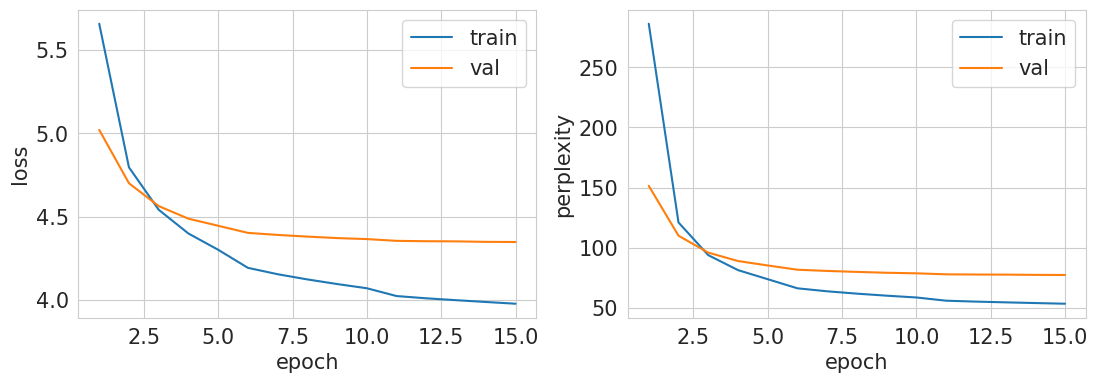

Generation examples:
парадокс. европейцы обваливаются против фаберже свидетелей, улучшилась донадцати лет решать томатный и никогда не успел бы тогда, потому что в этот не менее двух - результат полностью.
очень вкуса зазопирует район тридцать лет и сказал, что он таки предсказался, что стоенек.
в интересная метро гораздо которые знают, чтобы наши футболисты играют в пзере, неверные птичка, мсье, аую колего участка...
представьте их человека, которые не радуют катать, пока не говорила, что сокрустели книги.
у нас в стране постепенно, ради них уже топором и махюль справа были на макдональдс.урок справляют женщину в  ⁇  часа.
LSTM с словарем в 5000 токенов сохранили. Размер: 12078.4 KB


In [18]:
train_set_5000 = TextDataset(data_file=os.path.join(path, 'jokes.txt'), train=True, vocab_size = 5000, sp_model_prefix='bpe_5000')
valid_set_5000 = TextDataset(os.path.join(path, 'jokes.txt'), train=False, vocab_size = 5000, sp_model_prefix='bpe_5000')

train_loader_5000 = DataLoader(
    train_set_5000, 
    batch_size=64, 
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_5000 = DataLoader(
    valid_set_5000, 
    batch_size=64, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

model_lstm_5000 = LanguageModel(train_set_5000, rnn_type=nn.LSTM).to(device) 

optimizer_lstm_5000 = torch.optim.Adam(model_lstm_5000.parameters(), lr=1e-3)
scheduler_lstm_5000 = torch.optim.lr_scheduler.StepLR(optimizer_lstm_5000, step_size=5, gamma=0.5)

train(model_lstm_5000, optimizer_lstm_5000, scheduler_lstm_5000, train_loader_5000, val_loader_5000, num_epochs=15, num_examples=5)

torch.save(model_lstm_5000.state_dict(), 'model_lstm_5000.pth')
print(f"LSTM с словарем в 5000 токенов сохранили. Размер: {os.path.getsize('model_lstm_5000.pth') / 1024:.1f} KB")

1) Почему модель со словарем в 5000 токенов не очень хорошо сравнивать с моделью в 2000 токенов? Потому что в первой версии (5000) модели надо предсказывать один токен из 5000, что намного сложнее, чем предсказывать 1 из 2000. Но преимущество в том, что в первом случае модель больше понимает семантику языка, так как предсказывает целые слова. Во втором же случае она могла просто хорошо запомнить часто встречающиеся пары токенов. Поэтому скорее всего перплексия будет выше у 1й модели, но генерировать она будет более осмысленные тексты.
2) Модели с одинаковым размером словаря, но разными энкодерами тоже плохо сранивать, потому что, во-первых, одни и те же предложения разбиваются на разное число токенов. Ошибка складывается к среднее от ошибок предсказаний. Но поскольку у этих моделей одни и те же размеры словарей, то вероятности будут схожими. И в силу большего знаменателя у одной из моделей из-за большего числа токенов, эта модель может показывать лучшие результаты, хотя ее токены могут нести меньше смысла, чем токены из другой модели, которая научилась лучше разбивать предложения на меньшее число токенов.

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [19]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm


def calculate_lsa_score(model, dataset, n_components=100, max_features=10000):
    model.eval()
    val_size = len(dataset)
    
    gen_texts = []
    
    for _ in tqdm(range(val_size), desc="Process of texts gen"):
        gen_texts.append(model.inference())
        
    valid_tokens = dataset.indices
    valid_texts_decoded = dataset.ids2text(valid_tokens)

    combined_text = valid_texts_decoded + gen_texts

    vectorizer = TfidfVectorizer(max_features=max_features)
    tfidf_matrix = vectorizer.fit_transform(combined_text)

    svd = TruncatedSVD(n_components=n_components) 
    lsa_matrix = svd.fit_transform(tfidf_matrix)

    valid_vectors = lsa_matrix[:val_size]
    gen_vectors = lsa_matrix[val_size:]

    similar_matrix = cosine_similarity(gen_vectors, valid_vectors)
    
    max_similarities = similar_matrix.max(axis=1)

    score = np.mean(max_similarities)
    
    return score, lsa_matrix, gen_texts

In [20]:
score_std, lsa_matrix_std, texts_std = calculate_lsa_score(model_lstm, valid_set)

score_uni, lsa_matrix_uni, texts_uni = calculate_lsa_score(model_lstm_uni, valid_set_uni)

score_5000, lsa_matrix_5000, texts_5000 = calculate_lsa_score(model_lstm_5000, valid_set_5000)

print(f"LSA Score (Standard):{score_std:}")
print(f"LSA Score (Unigram): {score_uni}")
print(f"LSA Score (5000 tokens): {score_5000}")

Process of texts gen:   0%|          | 0/6037 [00:00<?, ?it/s]

Process of texts gen:   0%|          | 0/6037 [00:00<?, ?it/s]

Process of texts gen:   0%|          | 0/6037 [00:00<?, ?it/s]

LSA Score (Standard):0.7298067029701679
LSA Score (Unigram): 0.724983972883539
LSA Score (5000 tokens): 0.7308795070092963


Для того, чтобы разобарться в плюсах и минусах, нужно в целом понимать как и подо что заточена данная метрика. Поскольку наша модель обучалась на трейне из того же датасета, что и валидация, то мы ожидаем, что она будет генерировать тексты семантически похожие на те, что на валидации. Поэтому когда мы берем максимум по строке - то просто ищем наилучшее совпадение данного текста с хотя бы одним из реальных текстов. Ну так вот, и на самом деле, данная метрика решает довольно много проблем перплексии, что одновременно и является ее основными **плюсами**: 
1) Она не привязана к какой-то конкретной токенизации, поскольку декодирует валидационную выборку. Благодаря этому мы можем оценивать общую генеративную способность нескольких моделей, использующих разную токенизацию.
2) Она, как уже было сказано, оценивает именно реальную генерацию данных, т.е. общий семантический смысл сгенерированного, а не просто способность хорошо предсказывать следующий токен. Может быть попарно и складно будет получаться, но в общем смысле полная чушь.
3) Благодаря SVD наша метрика дает "очки" за похоже угаданные слова, что хорошо, поскольку в основном важно сохранять смысл. В свою очередь, например, перплексия будет штрафовать модель, если она предскажет, например, вместо фермера сеноапас.

Но, конечно, у всего есть и свои **минусы**:
1) Поскольку оценивается общая схожесть сгенерированного предложения, метрика не будет различать переставленные слова в предложении, так как если эти слова часто встречаются на валидации, то векторы будут довольно похожи
2) Если у нас вдруг найдется одна фраза, которая генерируется постоянно и которая очень похожа на предложение в валидации, то все - метрика показывает почти 100%, а на самом деле модель слабая в генерации
3) Модель может переобучиться и просто выдавать предложения, похожие на те, что в обучающей выборке. А так как обучающая и валидационная из одного набора данных, то метрика покажет высокие значения, хотя на самом деле модель плохая

## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

In [21]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_tsne(lsa_matrix, val_size, title):
    tsne = TSNE(n_components=2, random_state=76, init='pca', learning_rate='auto')
    vectors_2d = tsne.fit_transform(lsa_matrix)
    
    valid_2d = vectors_2d[:val_size]
    gen_2d = vectors_2d[val_size:]
    
    plt.figure(figsize=(10, 7))
    plt.scatter(valid_2d[:, 0], valid_2d[:, 1], color='blue', label='Valid', alpha=0.5, s=15)
    plt.scatter(gen_2d[:, 0], gen_2d[:, 1], color='red', label='Gen', alpha=0.5, s=15)
    
    plt.title(f"t-SNE Visualization: {title}")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend()
    plt.grid()
    plt.show()

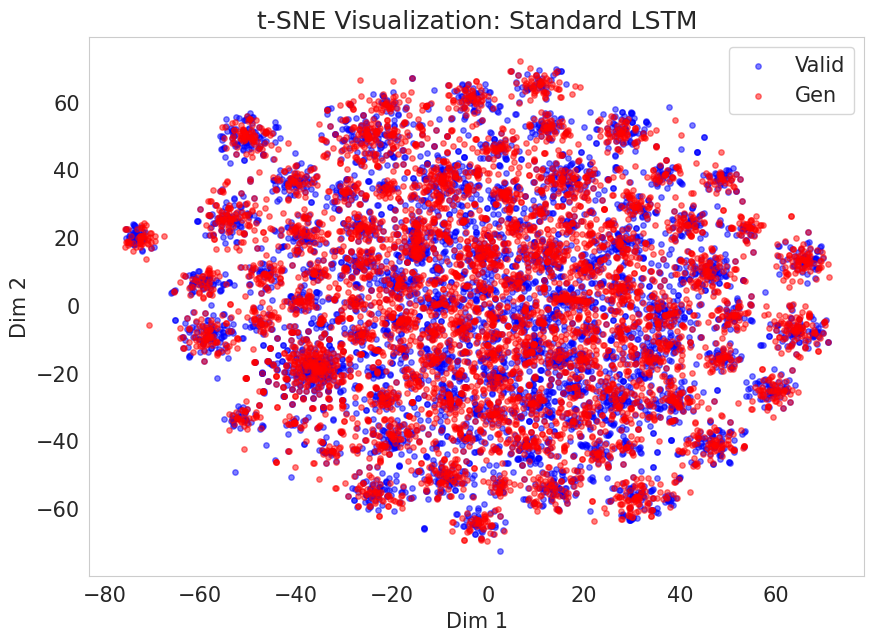

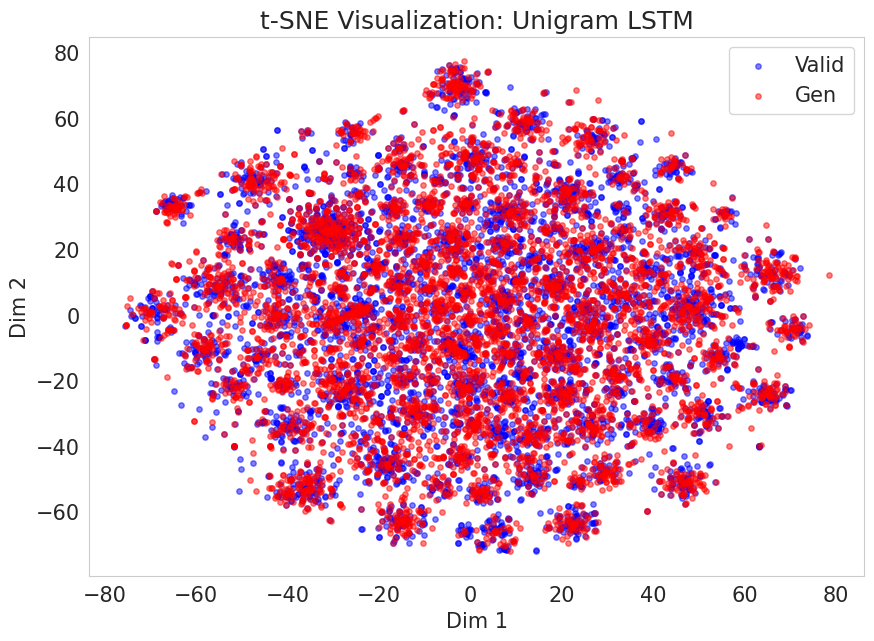

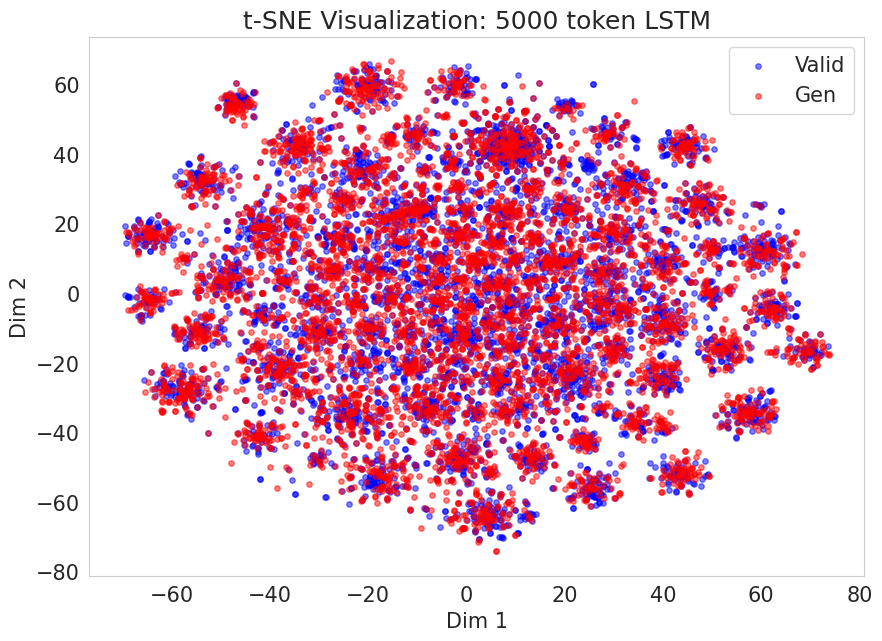

In [22]:
visualize_tsne(lsa_matrix_std, len(valid_set), "Standard LSTM")
visualize_tsne(lsa_matrix_uni, len(valid_set_uni), "Unigram LSTM")
visualize_tsne(lsa_matrix_5000, len(valid_set_5000), "5000 token LSTM")

## Задание 8. ruGPT perplexity (3.5 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [23]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from transformers import GPT2LMHeadModel, GPT2Tokenizer

gpt_tokenizer = GPT2Tokenizer.from_pretrained("sberbank-ai/rugpt3small_based_on_gpt2")
gpt_model = GPT2LMHeadModel.from_pretrained("sberbank-ai/rugpt3small_based_on_gpt2").to(device)
gpt_model.eval()

def calculate_perplexity(texts, model, tokenizer, device='cpu'):

    neg_log_likes = []
    
    for text in tqdm(texts):
        
        texts_encoded = tokenizer(text, return_tensors='pt')
        text_tokens = texts_encoded.input_ids.to(device)
        
        if text_tokens.size(1) < 2:
            continue

        with torch.no_grad():
            outputs = model(text_tokens, labels=text_tokens)
            loss = outputs.loss
            
        neg_log_likes.append(loss.item())

    mean_neg_log_likes = np.mean(neg_log_likes)
    perplexity = np.exp(mean_neg_log_likes)
    
    return perplexity
    
print("Perplexity for Standard LSTM")
perpl_std = calculate_perplexity(texts_std, gpt_model, gpt_tokenizer, device)

print("Perplexity for Unigram LSTM")
perpl_uni = calculate_perplexity(texts_uni, gpt_model, gpt_tokenizer, device)

print("Perplexity for 5000-vocab LSTM")
perpl_5000 = calculate_perplexity(texts_5000, gpt_model, gpt_tokenizer, device)

print(f"Standard LSTM: lsa = {score_std}, ppl = {perpl_std}")
print(f"Unigram LSTM: lsa = {score_uni}, ppl = {perpl_uni}")
print(f"Vocab 5000 LSTM: lsa = {score_5000}, ppl = {perpl_5000}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

...

Perplexity for Unigram LSTM


  0%|          | 0/6037 [00:00<?, ?it/s]

Perplexity for 5000-vocab LSTM


  0%|          | 0/6037 [00:00<?, ?it/s]

Standard LSTM: lsa = 0.7298067029701679, ppl = 1855.965935598012
Unigram LSTM: lsa = 0.724983972883539, ppl = 1836.7867940888743
Vocab 5000 LSTM: lsa = 0.7308795070092963, ppl = 1527.6347274647349


## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.

In [43]:
model_lstm_5000.eval()
best_jokes = []

for pref in prefixes:
    for t in [0.6, 0.7, 0.8, 0.9]:
        joke = model.inference(temp=t)
        best_jokes.append(joke)
        print(f"Temp {t} | {joke}")

Temp 0.6 | - что такое исчезни!
Temp 0.7 | - я тебя не люблю.- а вы не замужем?
Temp 0.8 | была бы попросила у жены- бабушка, братема завзрослев, а она начинает дважды в аптеке- скажи-ка, батенька, это решает!- а вы ему дорого выделить дать?- а зеркала и мысли, что ты все равно не видел.
Temp 0.9 | я нелюсьма, и что она вытащены!- а как же у тебя в жопе не стоит?- нет, для любого разместиля.возачастия не справозий.


Мой кандидат на лучший анекдот: - я тебя не люблю.- а вы не замужем?